<a href="https://colab.research.google.com/github/JuniorC137x/Challenge-Telecom-X-an-lisis-de-evasion-de-clientes/blob/main/TelecomX_1LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [12]:
import pandas as pd
import requests

# Cargamos los datos desde la API (archivo JSON en GitHub)
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

respuesta = requests.get(url)
datos = respuesta.json()

print(f'Datos cargados: {len(datos)} registros')
print('Ejemplo de un registro:')
print(datos[0])


Datos cargados: 7267 registros
Ejemplo de un registro:
{'customerID': '0002-ORFBO', 'Churn': 'No', 'customer': {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}, 'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'}, 'internet': {'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}, 'account': {'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}}


#🔧 Transformación

In [13]:
# El JSON está anidado en sub-objetos: customer, phone, internet, account
# json_normalize aplana toda esa estructura en una sola tabla plana
df = pd.json_normalize(datos)

print('Dimensiones del DataFrame:', df.shape)
print()
df.head()


Dimensiones del DataFrame: (7267, 21)



,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [14]:
# Revisamos tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print()
print('Valores nulos por columna:')
print(df.isnull().sum())


Tipos de datos:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

Valores nulos por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.D

In [15]:
# Limpieza de datos

# 1. Charges.Total viene como texto en el JSON, lo convertimos a número
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# 2. Rellenamos valores nulos con la mediana
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(df['account.Charges.Total'].median())

# 3. Convertimos Churn a valor binario (1 = se fue, 0 = se quedó)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Etiquetamos SeniorCitizen para que sea más legible en los gráficos
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].map({1: 'Senior', 0: 'No Senior'})

print('Limpieza completada.')
print(f'Clientes que se fueron  (Churn): {df["Churn"].sum()}')
print(f'Clientes que se quedaron:        {(df["Churn"] == 0).sum()}')
print(f'Tasa de evasión: {df["Churn"].mean()*100:.1f}%')


Limpieza completada.
Clientes que se fueron  (Churn): 1869.0
Clientes que se quedaron:        5174
Tasa de evasión: 26.5%


#📊 Carga y análisis

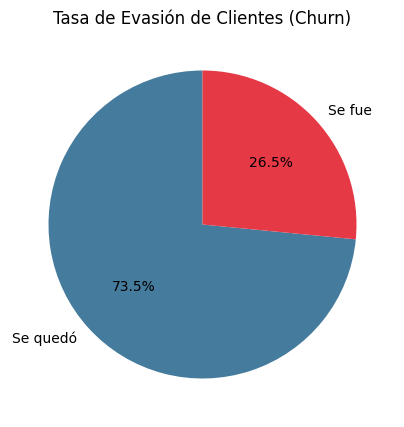

In [16]:
import matplotlib.pyplot as plt

COLOR_CHURN    = '#e63946'
COLOR_NO_CHURN = '#457b9d'

# Gráfico 1: Tasa general de Churn
conteo = df['Churn'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(conteo, labels=['Se quedó', 'Se fue'], autopct='%1.1f%%',
        colors=[COLOR_NO_CHURN, COLOR_CHURN], startangle=90)
plt.title('Tasa de Evasión de Clientes (Churn)')
plt.show()


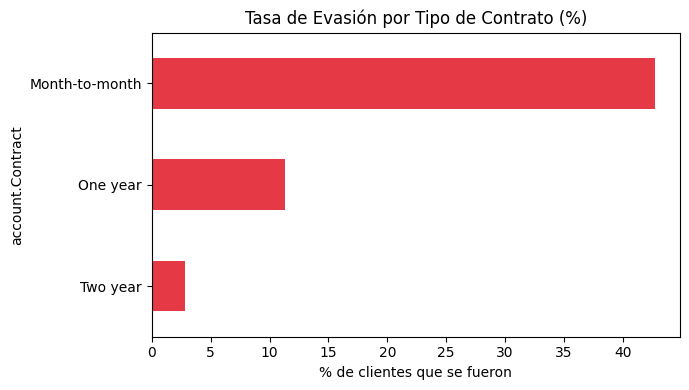

In [17]:
# Gráfico 2: Churn por tipo de contrato
churn_contrato = df.groupby('account.Contract')['Churn'].mean() * 100

plt.figure(figsize=(7, 4))
churn_contrato.sort_values().plot(kind='barh', color=COLOR_CHURN)
plt.title('Tasa de Evasión por Tipo de Contrato (%)')
plt.xlabel('% de clientes que se fueron')
plt.tight_layout()
plt.show()


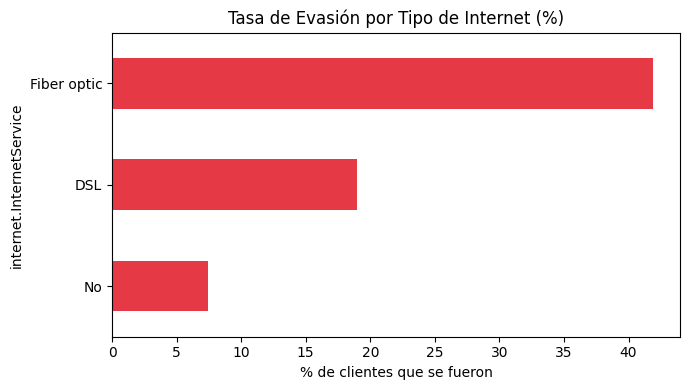

In [18]:
# Gráfico 3: Churn por tipo de servicio de internet
churn_internet = df.groupby('internet.InternetService')['Churn'].mean() * 100

plt.figure(figsize=(7, 4))
churn_internet.sort_values().plot(kind='barh', color=COLOR_CHURN)
plt.title('Tasa de Evasión por Tipo de Internet (%)')
plt.xlabel('% de clientes que se fueron')
plt.tight_layout()
plt.show()


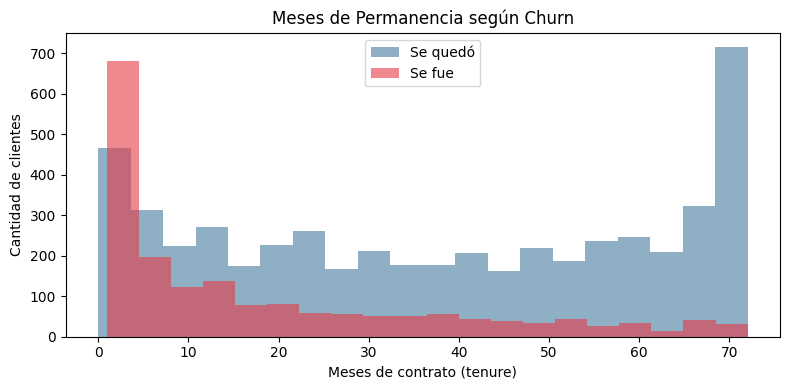

In [19]:
# Gráfico 4: Tiempo de permanencia (tenure) vs Churn
tenure_churn    = df[df['Churn'] == 1]['customer.tenure']
tenure_no_churn = df[df['Churn'] == 0]['customer.tenure']

plt.figure(figsize=(8, 4))
plt.hist(tenure_no_churn, bins=20, alpha=0.6, label='Se quedó', color=COLOR_NO_CHURN)
plt.hist(tenure_churn,    bins=20, alpha=0.6, label='Se fue',   color=COLOR_CHURN)
plt.title('Meses de Permanencia según Churn')
plt.xlabel('Meses de contrato (tenure)')
plt.ylabel('Cantidad de clientes')
plt.legend()
plt.tight_layout()
plt.show()


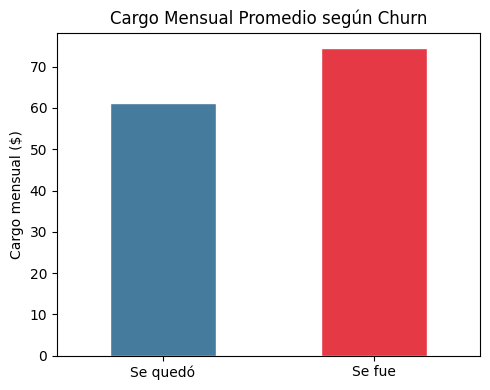

Cargo promedio - se fueron:    $74.44
Cargo promedio - se quedaron:  $61.27


In [20]:
# Gráfico 5: Cargo mensual promedio según Churn
cargo_promedio = df.groupby('Churn')['account.Charges.Monthly'].mean()
cargo_promedio.index = ['Se quedó', 'Se fue']

plt.figure(figsize=(5, 4))
cargo_promedio.plot(kind='bar', color=[COLOR_NO_CHURN, COLOR_CHURN], edgecolor='white')
plt.title('Cargo Mensual Promedio según Churn')
plt.ylabel('Cargo mensual ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Cargo promedio - se fueron:    ${df[df["Churn"]==1]["account.Charges.Monthly"].mean():.2f}')
print(f'Cargo promedio - se quedaron:  ${df[df["Churn"]==0]["account.Charges.Monthly"].mean():.2f}')


#📄 Informe final

In [21]:
# Resumen cuantitativo de los hallazgos
print('=== RESUMEN DEL ANALISIS ===')
print(f'Total de clientes analizados: {len(df)}')
print(f'Tasa de evasión (Churn): {df["Churn"].mean()*100:.1f}%')
print()
print('Churn por tipo de contrato:')
print((df.groupby('account.Contract')['Churn'].mean()*100).round(1).to_string())
print()
print('Churn por servicio de internet:')
print((df.groupby('internet.InternetService')['Churn'].mean()*100).round(1).to_string())
print()
print('Permanencia promedio - se fueron:   ', round(df[df['Churn']==1]['customer.tenure'].mean(), 1), 'meses')
print('Permanencia promedio - se quedaron: ', round(df[df['Churn']==0]['customer.tenure'].mean(), 1), 'meses')


=== RESUMEN DEL ANALISIS ===
Total de clientes analizados: 7267
Tasa de evasión (Churn): 26.5%

Churn por tipo de contrato:
account.Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

Churn por servicio de internet:
internet.InternetService
DSL            19.0
Fiber optic    41.9
No              7.4

Permanencia promedio - se fueron:    18.0 meses
Permanencia promedio - se quedaron:  37.6 meses


## Conclusiones

Con base en el análisis exploratorio realizado, se identificaron los siguientes factores asociados a la evasión de clientes en TelecomX:

**1. El tipo de contrato es el factor más determinante.**
Los clientes con contrato mes a mes presentan la tasa de evasión más alta. La falta de compromiso a largo plazo facilita la salida. Los clientes con contratos anuales o bianuales son significativamente más fieles.

**2. El servicio de fibra óptica concentra la mayor evasión.**
A pesar de ser el servicio más costoso, la fibra óptica registra más Churn que el DSL. Esto indica que los clientes no perciben que el precio pagado justifica la experiencia recibida, posiblemente por problemas de calidad o soporte.

**3. Los clientes nuevos son los más vulnerables.**
La mayoría de los clientes que se van llevan menos de 12 meses en la empresa. Los primeros meses son críticos para la fidelización.

**4. Los cargos mensuales elevados se asocian con mayor evasión.**
Los clientes que abandonaron pagaban en promedio más por mes, lo que refuerza que la percepción de valor es un problema central.

**Recomendación:** TelecomX debería priorizar la retención de clientes con contrato mes a mes, servicio de fibra óptica y menos de un año de antigüedad, ya que ese perfil concentra el mayor riesgo de evasión.
